In [ ]:
import matplotlib.pyplot as plt
import dartlabplot as dlp
import matplotlib.gridspec as gridspec

%matplotlib widget

# Create figure
fig = plt.figure(figsize=(10, 8))
fig.canvas.header_visible = False

# Define GridSpec
gs = gridspec.GridSpec(10, 10, figure=fig)

# Create subplots of varying sizes and shapes
ax1 = fig.add_subplot(gs[2:5, 0:4]) # row, col
ax2 = fig.add_subplot(gs[6:8, 0:2])
ax3 = fig.add_subplot(gs[6:8, 2:4])
ax4 = fig.add_subplot(gs[2:8, 5:10])

plotter = dlp.Lorenz96(fig, ax1, ax2, ax3, ax4)



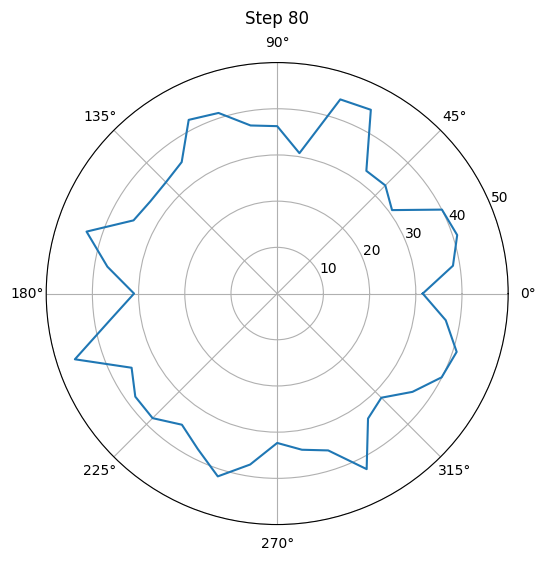

In [10]:
from lorenz_96 import Lorenz96
import numpy as np
import matplotlib.pyplot as plt
from IPython.display import display, clear_output

#DART L96
#L96.time_step_days    = 0;
#L96.time_step_seconds = 0;
#L96.delta_t           = 0.05;
#L96.forcing    = 8;
#L96.model_size = 40;
#L96.state_loc  = (0:L96.model_size - 1) / L96.model_size;


# Initialize the state
model_size = 40  # Number of variables in the system
#x = np.random.rand(N)  # Initial state
F = np.float64(8)  # Forcing term
dt = np.float64(0.05)  # Time step
steps = 80  # Number of steps to simulate
ens_size = 10 # Number of ensemble members
x = np.zeros(model_size) # one ensemble member TRUTH
x_t = np.zeros(model_size+1)
x_theta = np.zeros(model_size+1)
x_t = np.zeros(model_size+1)

l96 = Lorenz96(model_size)

# initalize l96 truth
x[:] = F  # true forcing
x[0] = 1.001 * F

# polar coordinates
x_theta[0:-1] = np.array([2*np.pi /(model_size) * i for i in range(model_size)])




# Setup the polar plot
fig = plt.figure(figsize=(10, 6))
plt.ion()  # Turn on interactive mode
ax = plt.subplot(111, projection='polar')  # Set up polar axes

ymin = 0  # Adjust as needed based on your data's expected range
ymax = 50  # Adjust as needed
ax.set_ylim([ymin, ymax])

for i in range(steps):
    x = l96.step(x, F, dt)  # Update each model's state
    x_t[model_size] = x[0]
    x_t[0:model_size] = x
    x_t = x_t + 35
    # Clear the current plot
    clear_output(wait=True)
    
    # Plot the new data on polar axes
    ax.plot(x_theta, x_t)  # Use ax.plot for plotting on specific axes
    ax.set_title(f'Step {i+1}', va='bottom')
    ax.set_ylim([ymin, ymax])
    display(fig)  # Display the figure
    plt.pause(0.1)  # Pause a bit so the update is visible
    ax.clear()  # Clear the axes to prepare for the next plot

plt.ioff()  # Turn off interactive mode to prevent further updates

In [ ]:
print(x_t)

In [ ]:
plt.plot(x_t)

In [ ]:
a = np.arange(10)


In [ ]:
np.roll(a, -2)